# Elastic cross sections from partial-wave LROMs

We now vary all ten local Woods--Saxon parameters, train one reduced
model per partial-wave channel, and assemble the observable. OLS and the
weak ridge retained by the research study use identical snapshots,
bases, and predictors.

In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib-cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lrom import BasisConfig, InputSpace, MaxVol, ScatteringLROM, ScatteringProblem, get_runtime
from lrom.diagnostics import relative_l2

plt.style.use("seaborn-v0_8-whitegrid")
FAST = os.getenv("LROM_FULL_RUN", "0") != "1"
BACKEND = os.getenv("LROM_BACKEND", "cpu")       # cpu, gpu, or auto
PRECISION = os.getenv("LROM_PRECISION", "double") # double or single (GPU)
runtime = get_runtime(BACKEND, PRECISION)
print(f"mode={'quick' if FAST else 'full'}, runtime={runtime.name}, device={runtime.device}")

from lrom.physics import FULL_PARAMETER_NAMES
from lrom.diagnostics import pointwise_relative_error

mode=quick, runtime=numpy-cpu, device=CPU


In [2]:
l_max = 6 if FAST else 10
n_train, n_test = ((100, 20) if FAST else (500, 100))
problem = ScatteringProblem(
    potential="full_woods_saxon", target_a=40, target_z=20,
    lab_energy=14.1, l_max=l_max, mesh_points=400 if FAST else 800,
    target_binding_energy=342.052184,
)
center = problem.reference_omega
space = InputSpace(
    continuous={name: (.82*v, 1.18*v) for name, v in zip(FULL_PARAMETER_NAMES, center)},
    fixed={"E": 14.1, "A": 40, "Z": 20},
)
train_samples = space.sample(n_train, seed=1204)
test_samples = space.sample(n_test, seed=1205)
training = problem.generate_training_data(train_samples)
testing = problem.generate_training_data(test_samples)
angles = np.arange(2.0, 179.0, 2.0)
reference = problem.cross_sections_from_data(testing, angles)

In [3]:
methods = {}
for name, ridge in {"OLS": 0.0, "ridge-14": 1e-14}.items():
    model = ScatteringLROM(
        problem, BasisConfig(size=5 if FAST else 6),
        MaxVol(count=6 if FAST else 12, ridge=ridge),
        packing_strategy="padded",
    ).train(training)
    prediction = model.cross_sections(
        test_samples, angles, linear_solver=runtime.solve
    )
    error = pointwise_relative_error(prediction, reference, denominator_floor=1e-10)
    methods[name] = {"model": model, "prediction": prediction, "error": error}

pd.DataFrame([
    {
        "method": name,
        "median case error": np.median(value["error"], axis=1).mean(),
        "95th-percentile case error": np.quantile(np.median(value["error"], axis=1), .95),
        "worst matrix condition": max(
            value["model"].predict(row).condition_number(channel)
            for row in test_samples
            for channel in value["model"].problem.channels
        ),
    }
    for name, value in methods.items()
])

,method,median case error,95th-percentile case error,worst matrix condition
0,OLS,0.060429,0.144819,84917.453825
1,ridge-14,0.060428,0.144819,84926.337461


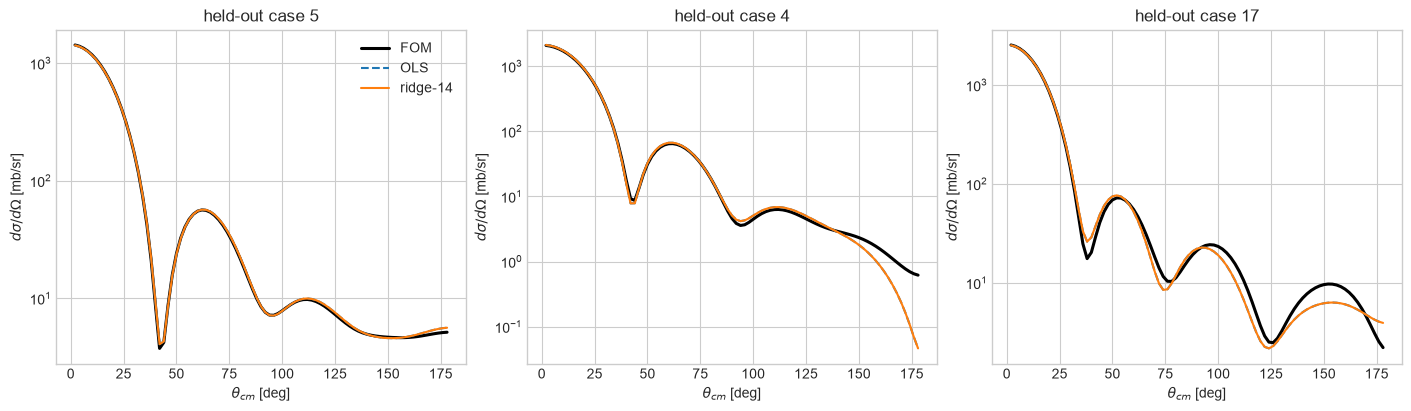

In [4]:
ranking = np.argsort(np.median(methods["ridge-14"]["error"], axis=1))
selected = ranking[[0, len(ranking)//2, -1]]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout="constrained")
for axis, index in zip(axes, selected):
    axis.semilogy(angles, reference[index], color="black", lw=2.2, label="FOM")
    for name, style in (("OLS", "--"), ("ridge-14", "-")):
        axis.semilogy(angles, methods[name]["prediction"][index], style, lw=1.5, label=name)
    axis.set(xlabel=r"$\theta_{cm}$ [deg]", ylabel=r"$d\sigma/d\Omega$ [mb/sr]",
             title=f"held-out case {index}")
axes[0].legend()
plt.show()

GPU mode changes only the batched reduced solves; training and the FOM
remain CPU operations. This is intentional: one fitted equation and one
observable implementation are tested regardless of deployment device.